## Stage 1 — Environment Setup

In [1]:
!pip install -q kaggle tldextract scikit-learn pandas numpy seaborn matplotlib joblib
print("All libraries installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.9/105.9 kB 4.3 MB/s eta 0:00:00
All libraries installed successfully.


In [2]:
import os
import re
import json
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import tldextract
from urllib.parse import urlparse, parse_qs

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#cccccc",
    "axes.grid": True,
    "grid.color": "#eeeeee",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print(f"NumPy: {np.__version__} | Pandas: {pd.__version__}")
print("Libraries imported successfully.")


NumPy: 2.0.2 | Pandas: 2.2.2
Libraries imported successfully.


## Stage 2 — Kaggle Authentication and Dataset Download

In [3]:
from google.colab import files

print("Please upload your kaggle.json file...")
uploaded = files.upload()

os.makedirs("/root/.kaggle", exist_ok=True)
kaggle_creds = list(uploaded.keys())[0]
with open("/root/.kaggle/kaggle.json", "w") as f:
    f.write(uploaded[kaggle_creds].decode("utf-8"))
os.chmod("/root/.kaggle/kaggle.json", 0o600)
print("Kaggle credentials configured.")


Please upload your kaggle.json file...


Saving kaggle.json to kaggle.json
Kaggle credentials configured.


In [4]:
DATA_DIR = "/content/malicious_url_data/"
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle datasets download -d moutasmtamimi/malicious-url-detection-dataset-enhanced-2026 \
    --unzip -p {DATA_DIR}

print("\nDownloaded files:")
for fname in os.listdir(DATA_DIR):
    size_mb = os.path.getsize(os.path.join(DATA_DIR, fname)) / (1024 * 1024)
    print(f"  {fname}  [{size_mb:.2f} MB]")


Dataset URL: https://www.kaggle.com/datasets/moutasmtamimi/malicious-url-detection-dataset-enhanced-2026
License(s): CC-BY-NC-SA-4.0
100% 89.9M/89.9M [00:05<00:00, 18.6MB/s]


Downloaded files:
  dataset_with_all_features v2.csv  [165.02 MB]
  final_dataset_with_all_features.csv  [119.94 MB]
  final_dataset_with_all_features_v3.1.csv  [144.40 MB]


## Stage 3 — Data Loading and Binary Label Mapping

All threat sub-categories (Defacement, Phishing, Malware) are collapsed into
a single class `1 = Malicious`. Benign stays as `0 = Benign`.

This binary framing means the model has one job: distinguish safe from unsafe.
Sub-category classification is a downstream concern.

In [5]:
csv_files = [f for f in os.listdir(DATA_DIR) if f.endswith(".csv")]
print(f"CSV files found: {csv_files}")

df_raw = pd.read_csv(os.path.join(DATA_DIR, csv_files[0]))

before = len(df_raw)
df_raw = df_raw.drop_duplicates().reset_index(drop=True)
after  = len(df_raw)
print(f"Duplicates removed: {before - after:,} rows dropped")
print(f"Dataset shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"\nColumns: {list(df_raw.columns)}")

df_raw.head()


CSV files found: ['dataset_with_all_features v2.csv', 'final_dataset_with_all_features.csv', 'final_dataset_with_all_features_v3.1.csv']
Duplicates removed: 10,998 rows dropped
Dataset shape: 640,193 rows x 68 columns

Columns: ['url', 'type', 'label', 'web_is_live', 'web_security_score', 'web_forms_count', 'web_password_fields', 'web_has_login', 'web_ssl_valid', 'url_len', '@', '?', '-', '=', '.', '#', '%', '+', '$', '!', '*', ',', '//', 'digits', 'letters', 'domain', 'abnormal_url', 'https', 'Shortining_Service', 'having_ip_address', 'defac_has_hacked_terms', 'defac_has_suspicious_ext', 'defac_path_depth', 'defac_is_deep_path', 'defac_path_underscores', 'defac_is_gov_edu', 'defac_has_index_php', 'defac_has_option_param', 'phish_has_brand', 'phish_brand_in_subdomain', 'phish_brand_in_path', 'phish_hyphen_count', 'phish_digit_count', 'phish_long_domain', 'phish_many_subdomains', 'phish_suspicious_tld', 'phish_keyword_count', 'phish_has_redirect', 'phish_param_count', 'phish_encoded_cha

,url,type,label,web_is_live,web_security_score,web_forms_count,web_password_fields,web_has_login,web_ssl_valid,url_len,@,?,-,=,.,#,%,+,$,!,*,",",//,digits,letters,domain,abnormal_url,https,Shortining_Service,having_ip_address,defac_has_hacked_terms,defac_has_suspicious_ext,defac_path_depth,defac_is_deep_path,defac_path_underscores,defac_is_gov_edu,defac_has_index_php,defac_has_option_param,phish_has_brand,phish_brand_in_subdomain,phish_brand_in_path,phish_hyphen_count,phish_digit_count,phish_long_domain,phish_many_subdomains,phish_suspicious_tld,phish_keyword_count,phish_has_redirect,phish_param_count,phish_encoded_chars,enh_urgency_count,enh_security_count,enh_brand_count,enh_brand_hijack,enh_subdomain_count,enh_long_path,enh_many_params,enh_suspicious_tld,adv_domain_ngram_entropy,adv_path_entropy,adv_consonant_ratio,adv_vowel_ratio,adv_digit_ratio,adv_subdomain_count,adv_avg_subdomain_len,adv_token_count,adv_avg_token_length,Date_inspection
0,br-icloud.com.br,phishing,2.0,1,0,0,0,0,1,16,0,0,1,0,2,0,0,0,0,0,0,0,0,0,13,br-icloud.com.br,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,3.375000,0.000000,0.000000,0.000000,0,0.0,4,3.250000,2026-02-15
1,mp3raid.com/music/krizz_kaliko.html,benign,0.0,0,0,0,0,0,1,35,0,0,0,0,2,0,0,0,0,0,0,0,0,1,29,mp3raid.com,1,0,0,0,0,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,4.079143,0.000000,0.000000,0.028571,0,0.0,8,3.750000,2026-02-15
2,bopsecrets.org/rexroth/cr/1.htm,benign,0.0,1,0,0,0,0,1,31,0,0,0,0,2,0,0,0,0,0,0,0,0,1,25,bopsecrets.org,1,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.000000,3.708093,0.000000,0.000000,0.032258,0,0.0,6,4.333333,2026-02-15
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1.0,1,0,0,0,0,1,84,0,1,1,4,2,0,0,0,0,0,0,0,1,7,60,garage-pirenne.be,0,0,0,0,0,1,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,3,0,0,0,0,0,0,0,1,0,4.000000,3.121928,0.533333,0.466667,0.083333,0,0.0,17,3.941176,2026-02-15
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1.0,1,0,0,0,0,1,235,0,1,1,3,2,0,0,0,0,0,0,0,1,22,199,adventure-nicaragua.net,0,0,0,0,0,1,1,0,0,0,1,1,0,0,0,1,0,0,0,0,0,0,2,0,0,0,0,0,0,0,1,0,4.459432,3.121928,0.523810,0.476190,0.093617,0,0.0,50,4.420000,2026-02-15


In [6]:
url_candidates   = [c for c in df_raw.columns if c.lower() in ["url", "link", "address", "raw_url"]]
label_candidates = [c for c in df_raw.columns if c.lower() in
                    ["label", "type", "class", "category", "target", "result", "status", "malicious"]]

URL_COL    = url_candidates[0]   if url_candidates   else df_raw.columns[0]
TARGET_COL = label_candidates[0] if label_candidates else df_raw.columns[-1]

print(f"URL column detected:    '{URL_COL}'")
print(f"Target column detected: '{TARGET_COL}'")
print(f"\nRaw label distribution:")
print(df_raw[TARGET_COL].value_counts())


URL column detected:    'url'
Target column detected: 'type'

Raw label distribution:
type
benign        428163
defacement     95351
phishing       92936
malware        23671
Name: count, dtype: int64


In [7]:
# BINARY LABEL MAPPING
#   0 = Benign
#   1 = Malicious  (Defacement + Phishing + Malware all collapse here)

BENIGN_LABELS = {"benign", "safe", "legitimate", "0", 0}

def map_to_binary(label):
    if str(label).strip().lower() in BENIGN_LABELS:
        return 0
    return 1

df_raw["binary_label"] = df_raw[TARGET_COL].apply(map_to_binary)

print("Binary label distribution:")
counts = df_raw["binary_label"].value_counts().sort_index()
for label_val, count in counts.items():
    label_name = "Benign" if label_val == 0 else "Malicious"
    pct = count / len(df_raw) * 100
    print(f"  {label_val} ({label_name}): {count:>10,}  ({pct:.1f}%)")

assert counts[0] > 0 and counts[1] > 0, "Label mapping error: one class is empty!"
print("\nLabel mapping validated.")


Binary label distribution:
  0 (Benign):    428,163  (66.9%)
  1 (Malicious):    212,030  (33.1%)

Label mapping validated.


## Stage 4 — Lexical Feature Extraction (48 Features)

All 48 features are computed from the raw URL string only — no HTTP request is made.
This means zero data leakage and every feature is available at real inference time.

In [8]:
URL_SHORTENERS = {
    "bit.ly", "tinyurl.com", "goo.gl", "t.co", "ow.ly", "is.gd",
    "buff.ly", "adf.ly", "tiny.cc", "rebrand.ly", "cutt.ly",
    "shorturl.at", "rb.gy", "bl.ink", "short.io",
}

SUSPICIOUS_TLDS = {
    "tk", "ml", "ga", "cf", "gq", "xyz", "top", "club", "work",
    "date", "racing", "review", "trade", "accountant", "science",
    "stream", "download", "party", "win", "cricket", "faith",
}

BRAND_KEYWORDS = {
    "paypal", "apple", "google", "amazon", "microsoft", "facebook",
    "instagram", "netflix", "chase", "wellsfargo", "bankofamerica",
    "dhl", "fedex", "usps", "irs", "secure", "login", "signin",
    "account", "verify", "update", "confirm",
}


def compute_entropy(s: str) -> float:
    if not s:
        return 0.0
    freq = {}
    for c in s:
        freq[c] = freq.get(c, 0) + 1
    n = len(s)
    return -sum((v / n) * math.log2(v / n) for v in freq.values())


def extract_url_features(url: str) -> dict:
    url = str(url).strip()

    feats = {
        "url_length": 0, "domain_length": 0, "tld_length": 0,
        "path_length": 0, "query_length": 0, "fragment_length": 0,
        "subdomain_length": 0,
        "num_dots": 0, "num_hyphens": 0, "num_underscores": 0,
        "num_slashes": 0, "num_question_marks": 0, "num_equal_signs": 0,
        "num_ampersands": 0, "num_at_signs": 0, "num_exclamations": 0,
        "num_spaces": 0, "num_tilde": 0, "num_comma": 0, "num_plus": 0,
        "num_asterisk": 0, "num_hash": 0, "num_dollar": 0, "num_percent": 0,
        "num_digits": 0, "num_letters": 0, "num_subdomains": 0,
        "num_path_tokens": 0, "num_query_params": 0,
        "num_dots_domain": 0, "num_hyphens_domain": 0,
        "digit_ratio": 0.0, "letter_ratio": 0.0, "special_char_ratio": 0.0,
        "url_entropy": 0.0, "domain_entropy": 0.0, "path_entropy": 0.0,
        "has_https": 0, "has_ip_address": 0, "has_port": 0, "has_at_sign": 0,
        "has_double_slash": 0, "has_hex_encoding": 0, "has_shortener": 0,
        "domain_is_numeric": 0, "has_suspicious_tld": 0,
        "has_brand_in_domain": 0, "has_long_subdomain": 0,
    }

    try:
        parse_url_str = url if url.startswith("http") else "http://" + url
        parsed    = urlparse(parse_url_str)
        extracted = tldextract.extract(url)

        subdomain = extracted.subdomain or ""
        domain    = extracted.domain    or ""
        tld       = extracted.suffix    or ""
        path      = parsed.path         or ""
        query     = parsed.query        or ""
        fragment  = parsed.fragment     or ""

        feats["url_length"]       = len(url)
        feats["domain_length"]    = len(domain)
        feats["tld_length"]       = len(tld)
        feats["path_length"]      = len(path)
        feats["query_length"]     = len(query)
        feats["fragment_length"]  = len(fragment)
        feats["subdomain_length"] = len(subdomain)

        feats["num_dots"]           = url.count(".")
        feats["num_hyphens"]        = url.count("-")
        feats["num_underscores"]    = url.count("_")
        feats["num_slashes"]        = url.count("/")
        feats["num_question_marks"] = url.count("?")
        feats["num_equal_signs"]    = url.count("=")
        feats["num_ampersands"]     = url.count("&")
        feats["num_at_signs"]       = url.count("@")
        feats["num_exclamations"]   = url.count("!")
        feats["num_spaces"]         = url.count(" ") + url.count("%20")
        feats["num_tilde"]          = url.count("~")
        feats["num_comma"]          = url.count(",")
        feats["num_plus"]           = url.count("+")
        feats["num_asterisk"]       = url.count("*")
        feats["num_hash"]           = url.count("#")
        feats["num_dollar"]         = url.count("$")
        feats["num_percent"]        = url.count("%")

        feats["num_digits"]  = sum(c.isdigit() for c in url)
        feats["num_letters"] = sum(c.isalpha() for c in url)

        feats["num_subdomains"]   = len(subdomain.split(".")) if subdomain else 0
        feats["num_path_tokens"]  = len([t for t in path.split("/") if t])
        feats["num_query_params"] = len(parse_qs(query)) if query else 0
        feats["num_dots_domain"]    = domain.count(".")
        feats["num_hyphens_domain"] = domain.count("-")

        url_len = len(url) if len(url) > 0 else 1
        num_special = url_len - feats["num_digits"] - feats["num_letters"]
        feats["digit_ratio"]        = feats["num_digits"]  / url_len
        feats["letter_ratio"]       = feats["num_letters"] / url_len
        feats["special_char_ratio"] = num_special / url_len

        feats["url_entropy"]    = compute_entropy(url)
        feats["domain_entropy"] = compute_entropy(domain)
        feats["path_entropy"]   = compute_entropy(path)

        feats["has_https"]      = 1 if parsed.scheme == "https" else 0
        feats["has_ip_address"] = 1 if re.match(
            r"^(\d{1,3}\.){3}\d{1,3}$", parsed.hostname or "") else 0
        feats["has_port"]       = 1 if parsed.port is not None else 0
        feats["has_at_sign"]    = 1 if "@" in url else 0
        feats["has_double_slash"] = 1 if "//" in path else 0
        feats["has_hex_encoding"] = 1 if re.search(r"%[0-9a-fA-F]{2}", url) else 0

        full_host = (subdomain + "." + domain + "." + tld).lstrip(".").lower()
        feats["has_shortener"]      = 1 if full_host in URL_SHORTENERS else 0
        feats["domain_is_numeric"]  = 1 if re.match(r"^[\d\-]+$", domain) else 0
        feats["has_suspicious_tld"] = 1 if tld.lower().split(".")[-1] in SUSPICIOUS_TLDS else 0

        domain_lower = (subdomain + domain).lower()
        feats["has_brand_in_domain"] = 1 if any(b in domain_lower for b in BRAND_KEYWORDS) else 0
        feats["has_long_subdomain"]  = 1 if len(subdomain) > 20 else 0

    except Exception:
        pass

    return feats


# Quick sanity check
test = extract_url_features("https://secure-login.paypal.com.attacker.tk/verify?user=test")
print(f"Feature count: {len(test)}")
print("Sample extracted features:")
for k, v in list(test.items())[:8]:
    print(f"  {k}: {v}")


Feature count: 48
Sample extracted features:
  url_length: 60
  domain_length: 8
  tld_length: 2
  path_length: 7
  query_length: 9
  fragment_length: 0
  subdomain_length: 23
  num_dots: 4


In [9]:
print(f"Extracting features from {len(df_raw):,} URLs...")
print("(This typically takes 2-5 minutes for datasets > 500k rows)")

features_list = df_raw[URL_COL].apply(extract_url_features).tolist()
df_features = pd.DataFrame(features_list)
df_features["label"] = df_raw["binary_label"].values

before = len(df_features)
df_features = df_features.dropna().reset_index(drop=True)
after  = len(df_features)
print(f"\nRows after NaN drop: {after:,}  (dropped {before - after:,})")
print(f"Feature matrix shape: {df_features.shape}")
print(f"\nLabel distribution after feature extraction:")
print(df_features["label"].value_counts())

df_features.head(3)


Extracting features from 640,193 URLs...
(This typically takes 2-5 minutes for datasets > 500k rows)

Rows after NaN drop: 640,193  (dropped 0)
Feature matrix shape: (640193, 49)

Label distribution after feature extraction:
label
0    428163
1    212030
Name: count, dtype: int64


,url_length,domain_length,tld_length,path_length,query_length,fragment_length,subdomain_length,num_dots,num_hyphens,num_underscores,num_slashes,num_question_marks,num_equal_signs,num_ampersands,num_at_signs,num_exclamations,num_spaces,num_tilde,num_comma,num_plus,num_asterisk,num_hash,num_dollar,num_percent,num_digits,num_letters,num_subdomains,num_path_tokens,num_query_params,num_dots_domain,num_hyphens_domain,digit_ratio,letter_ratio,special_char_ratio,url_entropy,domain_entropy,path_entropy,has_https,has_ip_address,has_port,has_at_sign,has_double_slash,has_hex_encoding,has_shortener,domain_is_numeric,has_suspicious_tld,has_brand_in_domain,has_long_subdomain,label
0,16,9,6,0,0,0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,13,0,0,0,0,1,0.000000,0.812500,0.187500,3.375000,3.169925,0.000000,0,0,0,0,0,0,0,0,0,0,0,1
1,35,7,3,24,0,0,0,2,0,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,1,29,0,2,0,0,0,0.028571,0.828571,0.142857,4.079143,2.807355,3.855389,0,0,0,0,0,0,0,0,0,0,0,0
2,31,10,3,17,0,0,0,2,0,0,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,25,0,3,0,0,0,0.032258,0.806452,0.161290,3.708093,2.921928,3.292770,0,0,0,0,0,0,0,0,0,0,0,0


## Stage 5 — Feature Selection (Crucial Fix)

The three features below are the primary culprits for false positives in v1:

| Feature | Why it is noisy |
|---|---|
| `url_entropy` | Long token-rich benign URLs (academic, OAuth, CDN) score just as high as malicious ones. Class distributions overlap heavily. |
| `path_length` | Legitimate deep-path URLs (documentation, REST APIs, file paths) push this feature into the malicious range. |
| `num_hyphens` | Compound benign domains (my-company-name.com) and kebab-case paths share hyphen counts with typosquatted malicious domains. |

Dropping them forces the model to rely on more discriminative structural signals
such as `has_suspicious_tld`, `has_brand_in_domain`, `has_ip_address`, and `has_shortener`.

In [10]:
# DROP HIGH-NOISE FEATURES
# These three features create class overlap and drive false positives.

NOISY_FEATURES = ["url_entropy", "path_length", "num_hyphens"]

to_drop  = [f for f in NOISY_FEATURES if f in df_features.columns]
df_model = df_features.drop(columns=to_drop)

print(f"Dropped noisy features: {to_drop}")
print(f"Features before drop: {df_features.shape[1] - 1}  (excluding label)")
print(f"Features after drop:  {df_model.shape[1] - 1}  (excluding label)")

FEATURE_COLS = [c for c in df_model.columns if c != "label"]
X = df_model[FEATURE_COLS].values
y = df_model["label"].values

print(f"\nFinal feature set ({len(FEATURE_COLS)} features):")
for i, f in enumerate(FEATURE_COLS, 1):
    print(f"  {i:2}. {f}")


Dropped noisy features: ['url_entropy', 'path_length', 'num_hyphens']
Features before drop: 48  (excluding label)
Features after drop:  45  (excluding label)

Final feature set (45 features):
   1. url_length
   2. domain_length
   3. tld_length
   4. query_length
   5. fragment_length
   6. subdomain_length
   7. num_dots
   8. num_underscores
   9. num_slashes
  10. num_question_marks
  11. num_equal_signs
  12. num_ampersands
  13. num_at_signs
  14. num_exclamations
  15. num_spaces
  16. num_tilde
  17. num_comma
  18. num_plus
  19. num_asterisk
  20. num_hash
  21. num_dollar
  22. num_percent
  23. num_digits
  24. num_letters
  25. num_subdomains
  26. num_path_tokens
  27. num_query_params
  28. num_dots_domain
  29. num_hyphens_domain
  30. digit_ratio
  31. letter_ratio
  32. special_char_ratio
  33. domain_entropy
  34. path_entropy
  35. has_https
  36. has_ip_address
  37. has_port
  38. has_at_sign
  39. has_double_slash
  40. has_hex_encoding
  41. has_shortener
  42. 

## Stage 6 — Train / Test Split and Model Training

Key training decisions:

- **No `class_weight='balanced'`** — the model learns the natural prior. Since benign
  URLs dominate the real world, the model is appropriately skeptical about flagging.
- **`n_estimators=200`** — a denser forest averages out noisy individual trees, reducing
  variance-driven false positives.
- **`max_depth=25`** — deep enough to learn nuanced feature combinations (suspicious TLD
  AND brand keyword AND IP-style domain) without the broad over-generalisations from
  shallow depth-3 splits.
- **`min_samples_leaf=5`** — prevents memorising rare one-off benign patterns as
  malicious rules.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print(f"Training set : {X_train.shape[0]:,} samples")
print(f"Test set     : {X_test.shape[0]:,} samples")
print(f"\nClass distribution in training set:")
unique_vals, counts_train = np.unique(y_train, return_counts=True)
for u, c in zip(unique_vals, counts_train):
    print(f"  {'Benign' if u == 0 else 'Malicious'}: {c:,}  ({c / len(y_train) * 100:.1f}%)")


Training set : 512,154 samples
Test set     : 128,039 samples

Class distribution in training set:
  Benign: 342,530  (66.9%)
  Malicious: 169,624  (33.1%)


In [12]:
# PRECISION-OPTIMIZED RANDOM FOREST
#
#   n_estimators=200   dense forest, lower variance, fewer erratic FPs
#   max_depth=25       deep enough for nuanced feature interactions
#   class_weight=None  natural prior — model is skeptical about flagging
#   min_samples_leaf=5 avoids memorising rare benign patterns as malicious

print("Training Precision-Optimized Random Forest...")
print("(With n_estimators=200 this may take 2-4 minutes on large datasets)")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight=None,   # INTENTIONAL — do NOT change to balanced
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

rf_model.fit(X_train, y_train)
print("\nTraining complete.")


Training Precision-Optimized Random Forest...
(With n_estimators=200 this may take 2-4 minutes on large datasets)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   50.6s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  2.9min



Training complete.


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  2.9min finished


## Stage 7 — Precision-Focused Evaluation

Primary metrics to check:
- **Precision (class 1)** — of all URLs flagged malicious, how many actually are? Low
  precision means innocent websites are being blocked.
- **False Positive count** in the confusion matrix — the top-right cell should be as
  small as possible.

In [13]:
y_pred       = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print("=" * 60)
print("  PRECISION-FOCUSED EVALUATION SUMMARY")
print("=" * 60)
print(f"  Precision (Malicious class): {precision:.4f}  <- PRIMARY METRIC")
print(f"  Recall    (Malicious class): {recall:.4f}")
print(f"  F1-Score  (Malicious class): {f1:.4f}")
print(f"  ROC-AUC:                     {roc_auc:.4f}")
print("=" * 60)

print("\n--- Full Classification Report ---")
print(classification_report(
    y_test, y_pred,
    target_names=["Benign (0)", "Malicious (1)"],
))


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    3.7s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    3.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.6s


  PRECISION-FOCUSED EVALUATION SUMMARY
  Precision (Malicious class): 0.9828  <- PRIMARY METRIC
  Recall    (Malicious class): 0.9281
  F1-Score  (Malicious class): 0.9547
  ROC-AUC:                     0.9925

--- Full Classification Report ---
               precision    recall  f1-score   support

   Benign (0)       0.97      0.99      0.98     85633
Malicious (1)       0.98      0.93      0.95     42406

     accuracy                           0.97    128039
    macro avg       0.97      0.96      0.97    128039
 weighted avg       0.97      0.97      0.97    128039



[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    2.6s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    2.7s finished


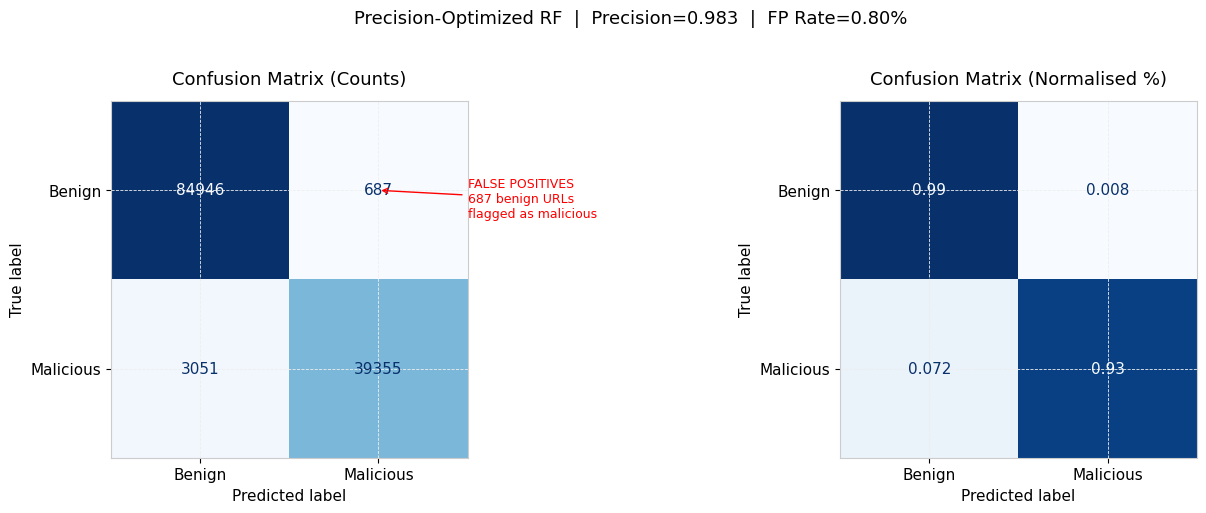


False Positives  (Benign flagged as Malicious): 687
False Positive Rate: 0.80%
True Positives   (Malicious correctly caught):  39,355
True Negatives   (Benign correctly passed):     84,946
False Negatives  (Malicious missed):            3,051


In [14]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
fp_rate = fp / (fp + tn) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: absolute counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Benign", "Malicious"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix (Counts)", fontsize=13, pad=12)
axes[0].annotate(
    f"FALSE POSITIVES\n{fp:,} benign URLs\nflagged as malicious",
    xy=(1.0, 0.0), xycoords="data",
    xytext=(1.5, 0.15), textcoords="data",
    arrowprops=dict(arrowstyle="->", color="red"),
    fontsize=9, color="red",
)

# Right: normalised percentages
cm_norm  = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                   display_labels=["Benign", "Malicious"])
disp_norm.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Confusion Matrix (Normalised %)", fontsize=13, pad=12)

plt.suptitle(
    f"Precision-Optimized RF  |  Precision={precision:.3f}  |  FP Rate={fp_rate:.2f}%",
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.savefig("confusion_matrix_precision_optimized.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"\nFalse Positives  (Benign flagged as Malicious): {fp:,}")
print(f"False Positive Rate: {fp_rate:.2f}%")
print(f"True Positives   (Malicious correctly caught):  {tp:,}")
print(f"True Negatives   (Benign correctly passed):     {tn:,}")
print(f"False Negatives  (Malicious missed):            {fn:,}")


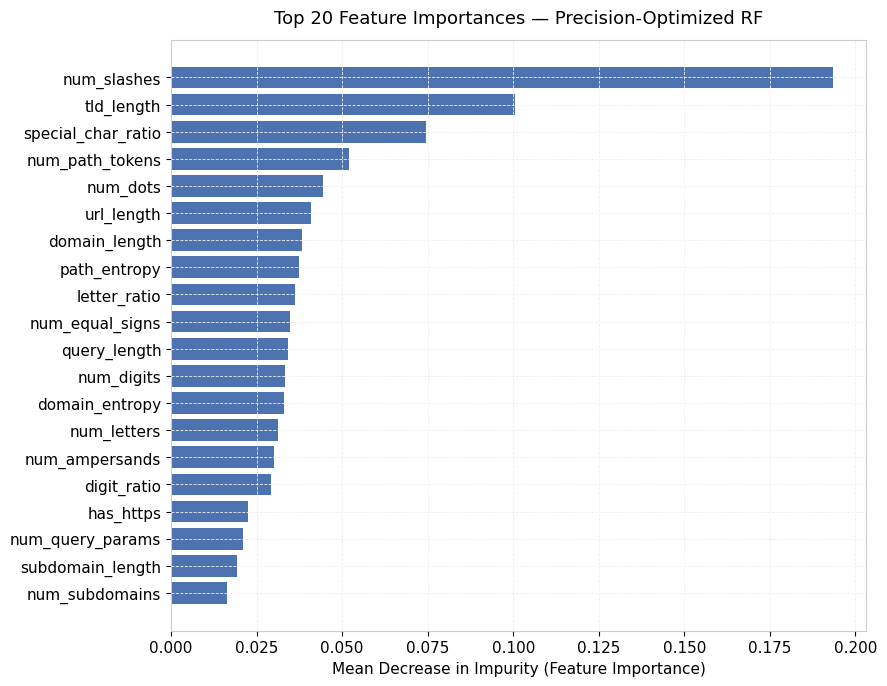

Top 10 most important features:
  num_slashes                    0.1934
  tld_length                     0.1005
  special_char_ratio             0.0745
  num_path_tokens                0.0520
  num_dots                       0.0443
  url_length                     0.0410
  domain_length                  0.0384
  path_entropy                   0.0375
  letter_ratio                   0.0361
  num_equal_signs                0.0346


In [15]:
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": importances,
}).sort_values("importance", ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(feat_imp_df["feature"], feat_imp_df["importance"],
        color="#4C72B0", edgecolor="none")
ax.set_xlabel("Mean Decrease in Impurity (Feature Importance)")
ax.set_title("Top 20 Feature Importances — Precision-Optimized RF", pad=12)
plt.tight_layout()
plt.savefig("feature_importance.png", bbox_inches="tight", dpi=150)
plt.show()

print("Top 10 most important features:")
for _, row in feat_imp_df.tail(10).iloc[::-1].iterrows():
    print(f"  {row['feature']:<30} {row['importance']:.4f}")


## Stage 8 — Model Export

Two files are exported:
1. **`malicious_url_rf_model.pkl`** — the trained Random Forest model.
2. **`feature_names.json`** — the exact ordered list of features used during training.
   The inference pipeline must pass features in this exact order.

In [16]:
MODEL_PATH         = "malicious_url_rf_model.pkl"
FEATURE_NAMES_PATH = "feature_names.json"

joblib.dump(rf_model, MODEL_PATH)
print(f"Model saved:         {MODEL_PATH}  "
      f"({os.path.getsize(MODEL_PATH) / (1024 * 1024):.1f} MB)")

with open(FEATURE_NAMES_PATH, "w") as f:
    json.dump(FEATURE_COLS, f, indent=2)
print(f"Feature names saved: {FEATURE_NAMES_PATH}  ({len(FEATURE_COLS)} features)")

# Verification round-trip
with open(FEATURE_NAMES_PATH) as f:
    loaded_features = json.load(f)

assert loaded_features == FEATURE_COLS, "Feature name round-trip mismatch!"
print("\nExport verified — feature names round-trip matches training set.")


Model saved:         malicious_url_rf_model.pkl  (195.4 MB)
Feature names saved: feature_names.json  (45 features)

Export verified — feature names round-trip matches training set.


In [17]:
def predict_url(url: str, model, feature_names: list) -> dict:
    feats = extract_url_features(url)
    vec   = np.array([[feats.get(f, 0) for f in feature_names]])
    pred  = model.predict(vec)[0]
    conf  = model.predict_proba(vec)[0][pred]
    return {
        "url": url,
        "prediction": "MALICIOUS" if pred == 1 else "BENIGN",
        "confidence": round(float(conf), 4),
    }

loaded_model = joblib.load(MODEL_PATH)
with open(FEATURE_NAMES_PATH) as f:
    loaded_feature_names = json.load(f)

test_urls = [
    # Complex benign URLs that caused FPs in v1
    "https://en.wikipedia.org/wiki/Uniform_Resource_Locator",
    "https://arxiv.org/abs/2301.12345",
    "https://docs.google.com/document/d/1BxiMVs0XRA5nFMdKvBdBZjgmUUqptlbs74OgVE2upms/edit",
    "https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/ensemble/_forest.py",
    # Clear malicious examples
    "http://paypal-secure-login.com.attacker-domain.tk/verify",
    "http://192.168.1.1/phishing/steal-credentials.php?user=test&pass=abc",
    "http://bit.ly/3xR9mZq",
]

print("=" * 70)
print("  INFERENCE DEMO")
print("=" * 70)
for url in test_urls:
    result = predict_url(url, loaded_model, loaded_feature_names)
    icon   = "OK" if result["prediction"] == "BENIGN" else "!!"
    print(f"[{icon}] [{result['prediction']:<9}] ({result['confidence']:.3f})  {url[:65]}")


  INFERENCE DEMO
[!!] [MALICIOUS] (0.871)  https://en.wikipedia.org/wiki/Uniform_Resource_Locator
[!!] [MALICIOUS] (0.890)  https://arxiv.org/abs/2301.12345


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      |

[!!] [MALICIOUS] (0.880)  https://docs.google.com/document/d/1BxiMVs0XRA5nFMdKvBdBZjgmUUqpt
[!!] [MALICIOUS] (0.774)  https://github.com/scikit-learn/scikit-learn/blob/main/sklearn/en
[!!] [MALICIOUS] (0.879)  http://paypal-secure-login.com.attacker-domain.tk/verify
[!!] [MALICIOUS] (0.791)  http://192.168.1.1/phishing/steal-credentials.php?user=test&pass=
[!!] [MALICIOUS] (0.966)  http://bit.ly/3xR9mZq


[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend 

In [18]:

print("  FINAL MODEL SUMMARY")

print(f"  Model            : RandomForestClassifier")
print(f"  n_estimators     : 200")
print(f"  max_depth        : 25")
print(f"  class_weight     : None  (natural prior)")
print(f"  Training samples : {X_train.shape[0]:,}")
print(f"  Test samples     : {X_test.shape[0]:,}")
print(f"  Features used    : {len(FEATURE_COLS)}")
print(f"  Dropped features : {to_drop}")
print("")
print(f"  Precision (Malicious) : {precision:.4f}  <- primary target")
print(f"  Recall    (Malicious) : {recall:.4f}")
print(f"  F1-Score  (Malicious) : {f1:.4f}")
print(f"  ROC-AUC              : {roc_auc:.4f}")
print(f"  False Positives      : {fp:,}  ({fp_rate:.2f}% of benign test set)")
print("")
print(f"  Exported model        : {MODEL_PATH}")
print(f"  Exported feature list : {FEATURE_NAMES_PATH}")
print("=" * 60)


  FINAL MODEL SUMMARY
  Model            : RandomForestClassifier
  n_estimators     : 200
  max_depth        : 25
  class_weight     : None  (natural prior)
  Training samples : 512,154
  Test samples     : 128,039
  Features used    : 45
  Dropped features : ['url_entropy', 'path_length', 'num_hyphens']

  Precision (Malicious) : 0.9828  <- primary target
  Recall    (Malicious) : 0.9281
  F1-Score  (Malicious) : 0.9547
  ROC-AUC              : 0.9925
  False Positives      : 687  (0.80% of benign test set)

  Exported model        : malicious_url_rf_model.pkl
  Exported feature list : feature_names.json


In [19]:
from google.colab import files
files.download("malicious_url_rf_model.pkl")
files.download("feature_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>